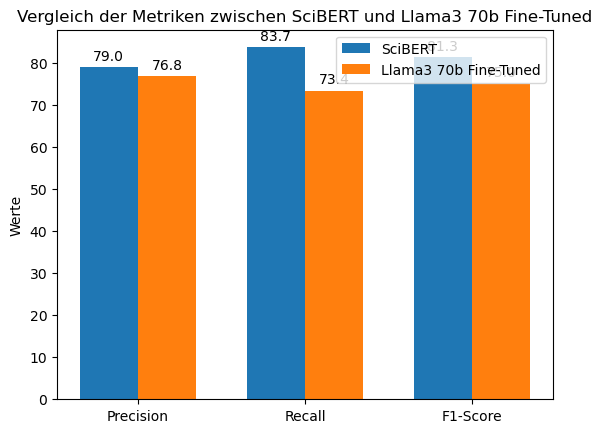

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Metriken für SciBERT und Llama3 70b Fine-Tuned
metrics = ['Precision', 'Recall', 'F1-Score']
scibert = [79.0, 83.7, 81.3]
llama3 = [76.8, 73.4, 75.0]

# Balkendiagramm erstellen
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, scibert, width, label='SciBERT')
bars2 = ax.bar(x + width/2, llama3, width, label='Llama3 70b Fine-Tuned')

# Labels und Titel hinzufügen
ax.set_ylabel('Werte')
ax.set_title('Vergleich der Metriken zwischen SciBERT und Llama3 70b Fine-Tuned')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Werte über die Balken schreiben
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

# Plot anzeigen
plt.show()


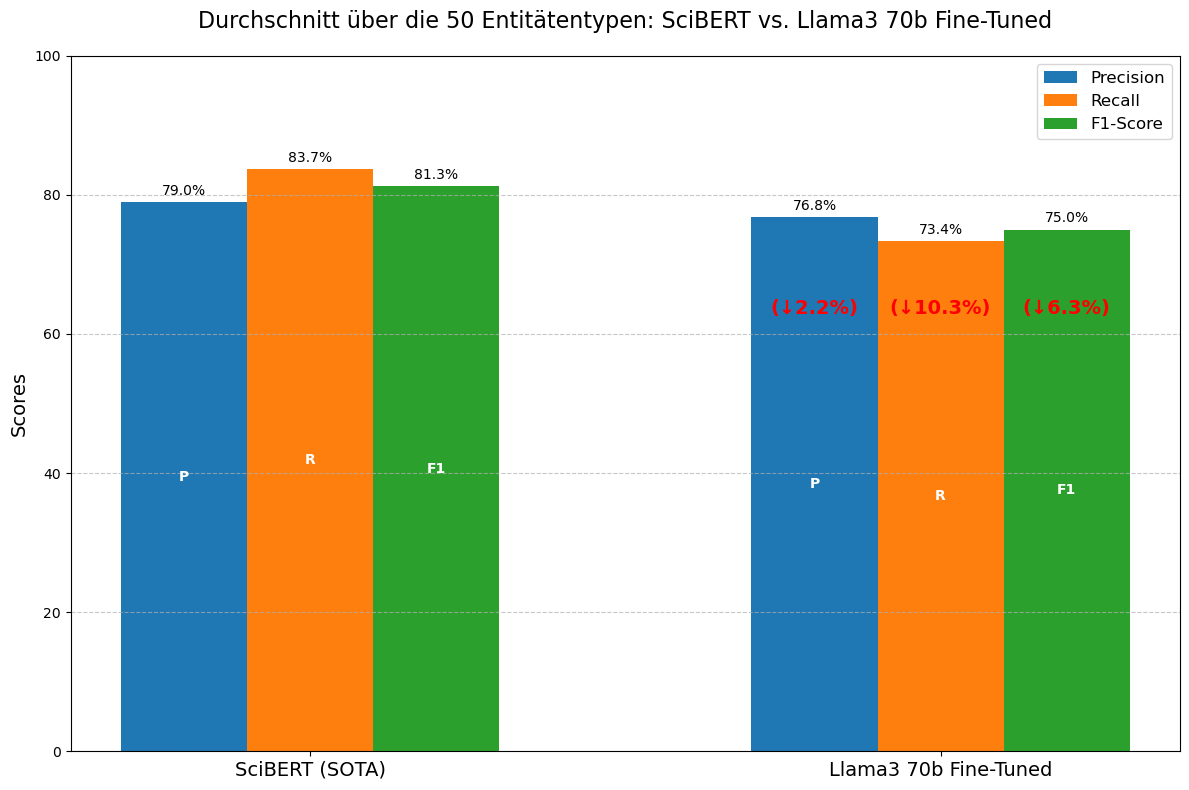

In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = ['SciBERT (SOTA)', 'Llama3 70b Fine-Tuned']
precision = [79.0, 76.8]
recall = [83.7, 73.4]
f1 = [81.3, 75.0]

# Differenzen berechnen
diff_precision = precision[0] - precision[1]
diff_recall = recall[0] - recall[1]
diff_f1 = f1[0] - f1[1]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width, precision, width, label='Precision')
rects2 = ax.bar(x, recall, width, label='Recall')
rects3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Durchschnitt über die 50 Entitätentypen: SciBERT vs. Llama3 70b Fine-Tuned', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14)  # Hier ist die Änderung
ax.legend(fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

def in_bar_labels(rects, labels):
    for rect, label in zip(rects, labels):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height/2,
                label,
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

in_bar_labels(rects1, ['P']*len(models))
in_bar_labels(rects2, ['R']*len(models))
in_bar_labels(rects3, ['F1']*len(models))

def autolabel(rects, diffs):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

        # Differenz für Llama3 hinzufügen
        if i == 1:  # Llama3 ist der zweite Balken
            ax.annotate(f'(↓{diffs:.1f}%)',
                        xy=(rect.get_x() + rect.get_width() / 2, 68),
                        xytext=(0, -15),  # 15 Punkte vertikaler Offset nach unten
                        textcoords="offset points",
                        ha='center', va='top', fontsize=14, color='red', fontweight='bold')

autolabel(rects1, diff_precision)
autolabel(rects2, diff_recall)
autolabel(rects3, diff_f1)

ax.set_ylim(0, 100)
fig.tight_layout()
plt.savefig('pics/50_entitys.png')
plt.show()